# Typing Speeds

**Category:** Data Cleaning  
**Dataset:** typing-speeds.csv — 168,594 rows, 11 columns  
**Objective:** Determine whether taking a typing course actually improves
speed, while correctly identifying and controlling for a confounding variable.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/typing-speeds.csv')
print(df.shape)
df.head(3)

(168594, 11)


,PARTICIPANT_ID,AGE,HAS_TAKEN_TYPING_COURSE,COUNTRY,LAYOUT,NATIVE_LANGUAGE,FINGERS,KEYBOARD_TYPE,ERROR_RATE,AVG_WPM_15,ROR
0,3,30,0,US,qwerty,en,1-2,full,0.511945,61.9483,0.2288
1,5,27,0,MY,qwerty,en,7-8,laptop,0.871080,72.8871,0.3675
2,7,13,0,AU,qwerty,en,7-8,laptop,6.685633,24.1809,0.0667


## 1. Dataset Exploration

This is by far the largest dataset in the portfolio. Running the standard
exploration sequence, paying special attention to AGE, since self-reported
survey data commonly contains implausible values.

In [2]:
print("Missing values per column: ")
print(df.isnull().sum())
print()
print("AGE summary statistics: ")
print(df['AGE'].describe())

Missing values per column: 
PARTICIPANT_ID              0
AGE                         0
HAS_TAKEN_TYPING_COURSE     0
COUNTRY                    20
LAYOUT                      0
NATIVE_LANGUAGE             0
FINGERS                     0
KEYBOARD_TYPE               0
ERROR_RATE                  0
AVG_WPM_15                  0
ROR                         0
dtype: int64

AGE summary statistics: 
count    168594.000000
mean         24.571859
std          11.239181
min           0.000000
25%          17.000000
50%          22.000000
75%          29.000000
max         120.000000
Name: AGE, dtype: float64


In [3]:
print("Rows with Age == 0: ", (df['AGE']==0).sum())
print("Rows with Age < 5: ", (df['AGE'] < 5).sum())
print("Rows with AGE > 95: ", (df['AGE'] > 95).sum())

Rows with Age == 0:  181
Rows with Age < 5:  1147
Rows with AGE > 95:  382


## 2. Cleaning: Filter Implausible Ages

The `AGE` column contains values from **0** to **120**, which include implausible ages for independent participants. A range of **5–95 years** was selected as a reasonable threshold before analysis, and the percentage of removed rows is reported to document the impact of this cleaning step.

In [4]:
before_count = len(df)

df_clean = df[(df['AGE'] >= 5) & (df['AGE'] <= 95)].copy()

after_count = len(df_clean)

removed = before_count - after_count
pct_removed = removed / before_count * 100

print(f"Removed {removed} rows ({pct_removed:.2f}%) with implausible ages.")
print(f"Remaning Rows: {after_count}")

Removed 1529 rows (0.91%) with implausible ages.
Remaning Rows: 167065


## 3. Cleaning: Handle Missing Country

Only **20 of 168,594** records contain a missing `COUNTRY` value (approximately **0.01%** of the dataset). Since this proportion is negligible and `COUNTRY` is not central to the analysis, these records can be removed.

In [5]:
print("Missing country values:", df_clean['COUNTRY'].isnull().sum())

df_clean = df_clean.dropna(subset='COUNTRY')

print("Rows after dropping missing countries:", len(df_clean))

Missing country values: 20
Rows after dropping missing countries: 167045


## 4. Naive Comparison: Course vs. No Course

A simple comparison of average typing speed between participants who have and have not taken a typing course provides an initial view of the data. However, this comparison does not account for other factors that may also influence typing speed.

In [6]:
naive_comparison = df_clean.groupby('HAS_TAKEN_TYPING_COURSE')['AVG_WPM_15'].agg(['mean', 'count'])
naive_comparison

,mean,count
HAS_TAKEN_TYPING_COURSE,,
0,49.019926,115522
1,54.383313,51523


Participants who reported taking a typing course have a higher average typing speed in the overall dataset. However, this comparison does not account for differences in typing technique or other potential confounding factors.

## 5. Identifying a Potential Confound

This section examines whether finger count acts as a confounding variable by comparing the two course groups.

In [7]:
finger_dist = pd.crosstab(df_clean['HAS_TAKEN_TYPING_COURSE'], df_clean['FINGERS'], normalize='index')
finger_dist

FINGERS,1-2,10+,3-4,5-6,7-8,9-10
HAS_TAKEN_TYPING_COURSE,,,,,,
0,0.151408,0.000009,0.154637,0.126868,0.173283,0.393795
1,0.060148,0.000000,0.076393,0.066650,0.134445,0.662364


## 6. Confound-Controlled Comparison

Typing speed is compared by course status **within each finger-count group** rather than across the entire dataset. This controls for differences in the number of fingers used, allowing for a fairer comparison of participants with similar typing techniques.

In [8]:
controlled_comparison = df_clean.groupby(['FINGERS', 'HAS_TAKEN_TYPING_COURSE'])['AVG_WPM_15'].mean().unstack()
controlled_comparison['gap'] = controlled_comparison[1] - controlled_comparison[0]
controlled_comparison.round(2)

HAS_TAKEN_TYPING_COURSE,0,1,gap
FINGERS,,,
1-2,40.04,39.23,-0.81
10+,42.79,NaN,NaN
3-4,41.11,40.63,-0.48
5-6,46.00,44.61,-1.39
7-8,50.13,49.91,-0.22
9-10,56.06,59.24,3.17


## 7. Typing Speed by Equipment and Layout

Typing speed is further examined across different finger-count groups, keyboard types, and keyboard layouts. The **10+ fingers** category is excluded from interpretation because it contains only one observation, making its average unreliable.

In [9]:
by_fingers = df_clean.groupby('FINGERS')['AVG_WPM_15'].agg(['mean', 'count']).sort_values('mean', ascending=False)
by_keyboard = df_clean.groupby('KEYBOARD_TYPE')['AVG_WPM_15'].agg(['mean', 'count']).sort_values('mean', ascending=False)

print("By fingers used: ")
print(by_fingers)
print()
print("By keyboard used: ")
print(by_keyboard)

By fingers used: 
              mean  count
FINGERS                  
9-10     57.424113  79619
7-8      50.070341  26945
5-6      45.734991  18090
10+      42.789900      1
3-4      41.023684  21800
1-2      39.920857  20590

By keyboard used: 
                    mean  count
KEYBOARD_TYPE                  
full           52.028419  73450
laptop         49.890745  90133
small          48.213949   1848
on-screen      35.614655   1614


## 8. Visualization: Confound-Controlled Comparison

This grouped bar chart compares average typing speed by course status within each finger-count group, making the controlled comparison easier to interpret.

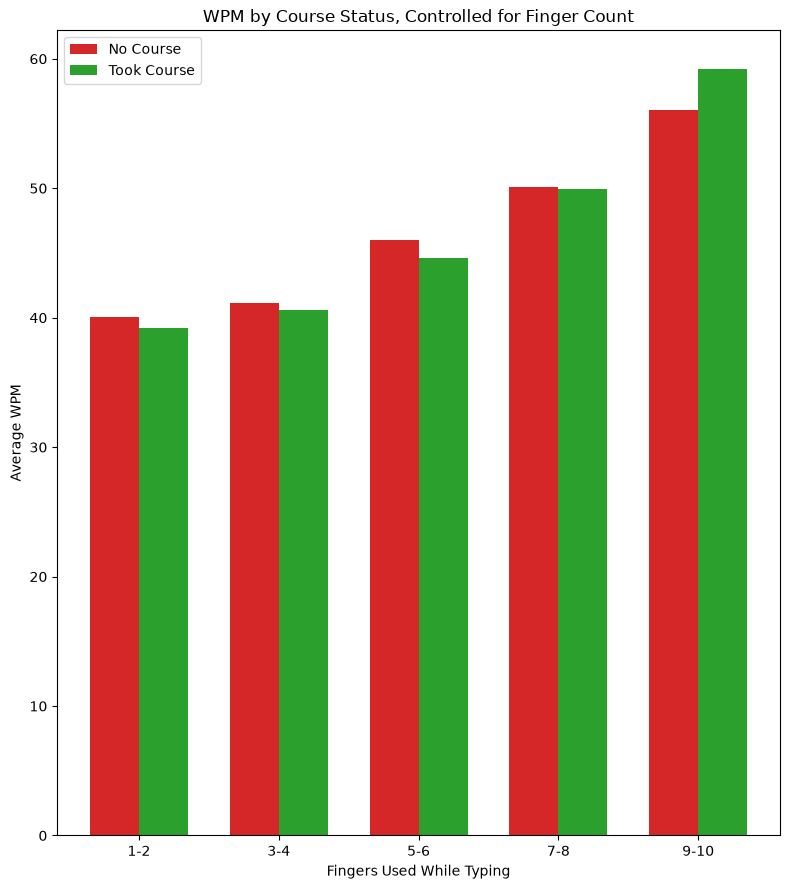

Chart Saved.


In [10]:
chart_data = controlled_comparison.drop(columns='gap').dropna()
finger_groups = chart_data.index.tolist()
x = np.arange(len(finger_groups))
width = 0.35

fig, ax = plt.subplots(figsize=(8,9))
ax.bar(x - width/2, chart_data[0], width, label='No Course', color='C3')
ax.bar(x + width/2, chart_data[1], width, label='Took Course', color='C2')

ax.set_xlabel("Fingers Used While Typing")
ax.set_ylabel("Average WPM")
ax.set_title("WPM by Course Status, Controlled for Finger Count")
ax.set_xticks(x)
ax.set_xticklabels(finger_groups)
ax.legend()

plt.tight_layout()

plt.savefig('../images/plots/wpm_by_course_controlled_for_fingers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")


## 9. My Own Question: How Big Is the Naive Gap Compared to the Controlled Gap?

This analysis compares the overall difference in typing speed before and after controlling for finger count, showing how much of the original gap remains.

In [11]:
naive_gap = naive_comparison.loc[1, 'mean'] - naive_comparison.loc[0, 'mean']
print(f"Naive (uncontrolled) gap: {naive_gap:.2f} WPM")

# Average of the per-group gaps, excluding the meaningless 10+ group
avg_controlled_gap = controlled_comparison['gap'].drop('10+').mean()
print(f"Average gap WITHIN finger-count groups: {avg_controlled_gap:.2f} WPM")

print(f"\nThe naive comparison overstates the course effect by roughly "
      f"{naive_gap - avg_controlled_gap:.2f} WPM once finger count is controlled for.")

Naive (uncontrolled) gap: 5.36 WPM
Average gap WITHIN finger-count groups: 0.05 WPM

The naive comparison overstates the course effect by roughly 5.31 WPM once finger count is controlled for.


## 11. Key Insights

- After filtering implausible ages and removing the small number of rows with missing country values, over **167,000** typing test records remained for analysis.

- A naive comparison suggests that people who have taken a typing course type **5.36 WPM** faster on average than those who have not.

- After controlling for **finger count**, the average difference drops to only **0.05 WPM**, indicating that much of the observed gap is explained by typing technique rather than course participation.

- Within most finger-count groups, participants who took a typing course showed little or no speed advantage, highlighting the importance of controlling for confounding variables before drawing conclusions.

- The **9–10 finger** group achieved the highest average typing speeds regardless of course status, suggesting that using more fingers is strongly associated with faster typing.

- The **10+ finger** category contained only a single observation and was excluded from interpretation to avoid drawing conclusions from an insufficient sample.

- This project demonstrates how comparing aggregated averages alone can produce misleading conclusions, emphasizing the value of subgroup analysis in exploratory data analysis.